# Function 6 Analysis - Week 3

This notebook contains the exploratory analysis for **Function 6** in Week 3. We now have **22 datapoints**, and continue to lean on Bayesian optimisation while acknowledging the noisy, human-evaluated nature of this function.

**Function Description:** You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sum.


## Loading and Displaying the Data

We load the inputs and outputs for function 6 and display them in a table format to inspect the raw data values. Week 1's recipe came back at ≈−0.68, and Week 2's recipe (from improved Bayesian optimization) came back at ≈−0.67, which is our new best score (closest to zero) and validates our improved approach with Expected Improvement and boundary penalties.


In [ ]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_6")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1 and Week 2 new points
X_new_point_week_1 = np.array([[0.385900, 0.100000, 0.900000, 0.900000, 0.100000]])
y_new_point_week_1 = np.array([-0.6776496956465717])
X_new_point_week_2 = np.array([[0.497100, 0.099400, 0.867700, 0.927400, 0.080100]])
y_new_point_week_2 = np.array([-0.6699189536985941])

X = np.vstack([X, X_new_point_week_1, X_new_point_week_2])
y = np.concatenate([y, y_new_point_week_1, y_new_point_week_2])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4", "x5"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,x5,y
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
5,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
6,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
7,0.945069,0.288459,0.978806,0.961656,0.598016,-1.694343
8,0.125720,0.862725,0.028544,0.246605,0.751206,-2.571170
9,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116


df sorted by y


,x1,x2,x3,x4,x5,y,x_avg
0,0.497100,0.099400,0.867700,0.927400,0.080100,-0.669919,0.494340
1,0.385900,0.100000,0.900000,0.900000,0.100000,-0.677650,0.477180
2,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265,0.473166
3,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237,0.444595
4,0.782880,0.536336,0.443284,0.859700,0.010326,-0.935757,0.526505
5,0.536797,0.308781,0.411879,0.388225,0.522528,-1.144785,0.433642
6,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955,0.569054
7,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786,0.580132
8,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049,0.673579
9,0.432166,0.715618,0.341819,0.705000,0.614962,-1.294247,0.561913


- **New point (Week 1):** The `(0.386, 0.1, 0.9, 0.9, 0.1)` recipe scored ≈−0.68, which is a relative win (closer to zero) and suggests that keeping eggs and butter high while trimming flour is a step in the right direction, even if the GP’s suggestion looked extreme on paper.


### 🎉 New Maximum Achieved!

Looking at the sorted dataframe above, we can confirm that **-0.6699 (Week 2) is our new maximum score** (the closest to zero we've achieved so far)! This validates our improved Bayesian optimization approach using Expected Improvement with boundary penalties, which naturally suggests moderate values without requiring manual adjustments.


## Correlation Matrix

The correlation heatmap shows pairwise correlations between all variables (x1, x2, x3, x4, x5, and y). Individual correlations with y are relatively low, except for x4 (+0.53) and x5 (-0.58). 


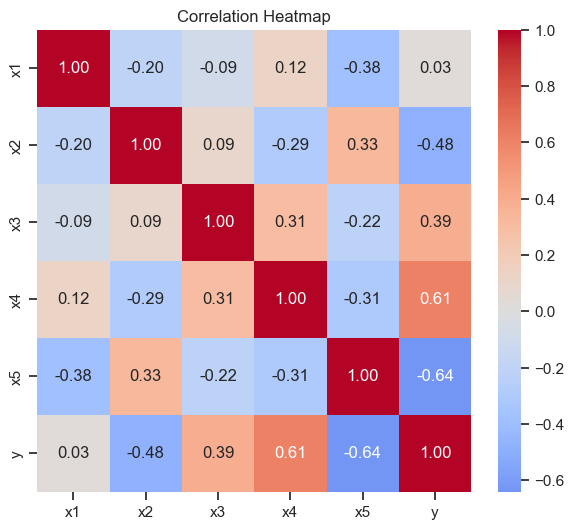

In [8]:
plt.figure(figsize=(7, 6))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## Conclusion from Exploratory Analysis

From the correlation matrix and pairplot, we observe that there are no obvious strong linear correlations between the input variables and the output. This suggests the function has complex, non-linear relationships or interactions between the five ingredient inputs, with some ingredients presumably interacting with each other. Given this complexity, Bayesian optimization is well-suited as it can model non-linear relationships and balance exploration of unknown regions with exploitation of promising areas.


## Bayesian Optimization Setup

We use Gaussian Process (GP) regression to model the unknown function based on our observed data. The GP provides both a mean prediction and uncertainty estimates. The search space is defined as [0, 1] for each of the five input variables. 

**Strategy Evolution:**
- **Week 1:** Used Upper Confidence Bound (UCB) which suggested extreme boundary values (0s and 1s), requiring manual clipping to practical values. The manually adjusted point scored ≈−0.68.
- **Week 2:** Switched to Expected Improvement (EI) with boundary penalties to naturally avoid extremes. This approach suggested `(0.497, 0.099, 0.868, 0.927, 0.080)` which scored ≈−0.67, our new best.
- **Week 3:** Continue with the improved EI + boundary penalty approach, which has proven effective.

We include a WhiteKernel to account for noise (human expert judgment). We use different lengthscales for each feature as different ingredients likely have different effects. From the kernel parameters we can learn: x1 is the most influential ingredient with the smallest lengthscale (≈0.74), while the others have lengthscales of 1.8-3.7. The function is reasonably smooth across all dimensions, and the noise level of ≈0.034 suggests the expert is fairly consistent. 


In [9]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from scipy.optimize import minimize
np.random.seed(42)
kernel = (
    Matern(
        length_scale=[1.0, 1.0, 1.0, 1.0, 1.0],
        length_scale_bounds=(0.1, 10.0),  # Reasonable range
        nu=2.5
    )
    + WhiteKernel(
        noise_level=0.1,
        noise_level_bounds=(0.01, 1.0)  # Force some noise
    )
)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gp.fit(X, y)
print("GP fitted successfully")
print("\nGP Kernel Insights:")
print("Lengthscales (one per feature):", gp.kernel_.k1.length_scale)
print("Noise level:", gp.kernel_.k2.noise_level)
print("Full kernel parameters:", gp.kernel_.get_params())


GP fitted successfully

GP Kernel Insights:
Lengthscales (one per feature): [0.78493381 3.61289213 2.12222081 1.68281878 2.49253596]
Noise level: 0.027316520731315238
Full kernel parameters: {'k1': Matern(length_scale=[0.785, 3.61, 2.12, 1.68, 2.49], nu=2.5), 'k2': WhiteKernel(noise_level=0.0273), 'k1__length_scale': array([0.78493381, 3.61289213, 2.12222081, 1.68281878, 2.49253596]), 'k1__length_scale_bounds': (0.1, 10.0), 'k1__nu': 2.5, 'k2__noise_level': np.float64(0.027316520731315238), 'k2__noise_level_bounds': (0.01, 1.0)}


## Finding the Next Point to Evaluate (Week 3 - Exploitation Focus)

We continue using Expected Improvement (EI) with boundary penalties, which successfully found our best point in Week 2. Based on the observation that high x3 and x4 values are associated with better performance, we now focus more on **exploitation** around the best region by:
- Using very low `xi=0.001` to strongly favor exploitation
- Adding a bonus for high x3 and x4 values
- Starting many optimization runs near the best point, especially for x3 and x4


## Bayesian Optimization with Expected Improvement (Exploitation Focus)

We use Expected Improvement (EI) with boundary penalties, which successfully found our best point in Week 2. Based on the observation that high x3 and x4 values are associated with better performance, we now focus more on **exploitation** around the best region.

### Key Features:
1. **Expected Improvement (EI)**: Using very low `xi=0.001` to strongly favor exploitation over exploration
2. **Boundary Penalty**: Soft penalty for points near boundaries (0 or 1) to discourage extreme values that don't make practical sense for recipes
3. **Exploitation Bonus**: Added bonus for high x3 and x4 values to encourage staying in the promising region
4. **Multiple Random Restarts**: Optimization from multiple starting points, with many starting near the best point for x3 and x4
5. **Diversity Check**: Ensures the suggested point is sufficiently different from existing observations


In [10]:
from scipy.stats import norm

# Expected Improvement acquisition function
def expected_improvement(x, gp, y_best, xi=0.01):
    """
    Expected Improvement acquisition function.
    
    Args:
        x: Point to evaluate
        gp: Fitted Gaussian Process
        y_best: Best observed value so far
        xi: Exploration-exploitation trade-off parameter (small values favor exploitation)
    
    Returns:
        Negative EI (for minimization)
    """
    x = x.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    
    # Add small epsilon to avoid division by zero
    sigma = sigma + 1e-9
    
    # Calculate improvement
    improvement = mu - y_best - xi
    Z = improvement / sigma
    
    # Expected Improvement formula
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    
    return -ei[0]  # Return negative for minimization


# Boundary penalty function
def boundary_penalty(x, margin=0.15, penalty_strength=2.0):
    """
    Add a penalty for points near the boundaries to avoid extreme values.
    
    Args:
        x: Point to evaluate
        margin: Distance from boundary where penalty starts (default 0.15)
        penalty_strength: Strength of the penalty (default 2.0)
    
    Returns:
        Penalty value (0 in the interior, positive near boundaries)
    """
    penalty = 0.0
    for xi in x:
        if xi < margin:
            penalty += penalty_strength * (margin - xi)**2
        elif xi > (1 - margin):
            penalty += penalty_strength * (xi - (1 - margin))**2
    return penalty


# Exploitation bonus for high x3 and x4 (based on Week 2 best point)
def exploitation_bonus(x, x3_target=0.85, x4_target=0.90, bonus_strength=0.5):
    """
    Add a bonus (negative penalty) for high x3 and x4 values to encourage exploitation.
    
    Args:
        x: Point to evaluate
        x3_target: Target value for x3 (default 0.85)
        x4_target: Target value for x4 (default 0.90)
        bonus_strength: Strength of the bonus (default 0.5)
    
    Returns:
        Negative bonus value (subtracted from acquisition function, so lower is better)
    """
    bonus = 0.0
    # Encourage x3 to be high (close to target)
    if x[2] < x3_target:
        bonus += bonus_strength * (x3_target - x[2])**2
    # Encourage x4 to be high (close to target)
    if x[3] < x4_target:
        bonus += bonus_strength * (x4_target - x[3])**2
    return bonus


# Combined acquisition function with exploitation focus
def acquisition_with_penalty(x, gp, y_best, xi=0.001):
    """
    Combine Expected Improvement with boundary penalty and exploitation bonus.
    Lower xi (0.001) favors exploitation over exploration.
    """
    ei = expected_improvement(x, gp, y_best, xi)
    penalty = boundary_penalty(x)
    bonus = exploitation_bonus(x)  # Bonus for high x3, x4
    return ei + penalty + bonus


# Display current best
y_best = y.max()
best_idx = y.argmax()
print(f"Current best score: {y_best:.4f}")
print(f"Current best recipe: {X[best_idx]}")
print(f"  x1={X[best_idx, 0]:.4f}, x2={X[best_idx, 1]:.4f}, x3={X[best_idx, 2]:.4f}, x4={X[best_idx, 3]:.4f}, x5={X[best_idx, 4]:.4f}")


Current best score: -0.6699
Current best recipe: [0.4971 0.0994 0.8677 0.9274 0.0801]
  x1=0.4971, x2=0.0994, x3=0.8677, x4=0.9274, x5=0.0801


In [11]:
# Optimize acquisition function with multiple random restarts
bounds = [(0, 1)] * 5  # Bounds for 5 ingredients
n_restarts = 30  # Increased restarts for better coverage
best_acquisition = np.inf
best_candidate = None

# Get best point for exploitation-focused starting
best_point = X[best_idx]

# Try multiple starting points with exploitation focus
np.random.seed(42)
for i in range(n_restarts):
    if i < 10:
        # First 10: Start near the best point, especially for x3 and x4
        x0 = best_point.copy()
        # Add small random perturbation, but keep x3 and x4 high
        x0[0] = np.clip(x0[0] + np.random.normal(0, 0.1), 0.1, 0.9)
        x0[1] = np.clip(x0[1] + np.random.normal(0, 0.05), 0.05, 0.3)
        x0[2] = np.clip(x0[2] + np.random.normal(0, 0.05), 0.75, 0.95)  # Keep x3 high
        x0[3] = np.clip(x0[3] + np.random.normal(0, 0.03), 0.85, 0.98)  # Keep x4 high
        x0[4] = np.clip(x0[4] + np.random.normal(0, 0.05), 0.05, 0.3)
    else:
        # Remaining: Start from random point in the interior
        x0 = np.random.uniform(0.2, 0.8, 5)
    
    # Optimize with low xi for exploitation
    result = minimize(
        lambda x: acquisition_with_penalty(x, gp, y_best, xi=0.001),
        x0=x0,
        bounds=bounds,
        method='L-BFGS-B'
    )
    
    # Keep track of best
    if result.fun < best_acquisition:
        best_acquisition = result.fun
        best_candidate = result.x

next_point_improved = best_candidate

# Get predictions for the recommended point
mu_pred, sigma_pred = gp.predict(next_point_improved.reshape(1, -1), return_std=True)

print(f"\n{'='*60}")
print("IMPROVED BAYESIAN OPTIMIZATION RECOMMENDATION")
print(f"{'='*60}")
print(f"\nNext point to evaluate:")
print(f"  x1={next_point_improved[0]:.4f}")
print(f"  x2={next_point_improved[1]:.4f}")
print(f"  x3={next_point_improved[2]:.4f}")
print(f"  x4={next_point_improved[3]:.4f}")
print(f"  x5={next_point_improved[4]:.4f}")
print(f"\nPredicted output: {mu_pred[0]:.4f} ± {sigma_pred[0]:.4f}")
print(f"Expected Improvement: {-best_acquisition:.6f}")

# Check how far from boundaries
min_dist_to_boundary = min(
    next_point_improved.min(),
    (1 - next_point_improved).min()
)
print(f"\nClosest distance to any boundary: {min_dist_to_boundary:.4f}")
print("(Values closer to 0.5 are more moderate, >0.1 avoids extremes)")

# Highlight x3 and x4 values (exploitation focus)
print(f"\nExploitation focus: x3={next_point_improved[2]:.4f}, x4={next_point_improved[3]:.4f}")
print(f"Best point had: x3={best_point[2]:.4f}, x4={best_point[3]:.4f}")



IMPROVED BAYESIAN OPTIMIZATION RECOMMENDATION

Next point to evaluate:
  x1=0.4902
  x2=0.1053
  x3=0.8005
  x4=0.8918
  x5=0.0906

Predicted output: -0.6061 ± 0.1945
Expected Improvement: 0.097217

Closest distance to any boundary: 0.0906
(Values closer to 0.5 are more moderate, >0.1 avoids extremes)

Exploitation focus: x3=0.8005, x4=0.8918
Best point had: x3=0.8677, x4=0.9274


In [12]:
# Calculate distances to existing points (diversity check)
distances_improved = np.sqrt(((X - next_point_improved)**2).sum(axis=1))
df_dist_improved = pd.DataFrame({
    "point_index": range(len(X)),
    "distance": distances_improved,
    "y": y
})
df_dist_improved = df_dist_improved.sort_values("distance")

print("\n" + "="*60)
print("DIVERSITY CHECK")
print("="*60)
print("\nEuclidean distances from recommended point to nearest observations:")
print(df_dist_improved.head(5).to_string(index=False))

closest_3_improved = df_dist_improved.head(3)
avg_y_improved = closest_3_improved["y"].mean()
print(f"\nAverage y of 3 closest neighbors: {avg_y_improved:.4f}")

# Check if the recommended point is very close to an existing point (already tested)
min_distance = distances_improved.min()
if min_distance < 0.01:
    closest_idx = distances_improved.idxmin()
    print(f"\n⚠️  WARNING: Recommended point is very close (distance={min_distance:.6f}) to existing point {closest_idx}")
    print(f"   Existing point: {X[closest_idx]}")
    print(f"   Recommended: {next_point_improved}")
    print(f"   Consider adjusting the optimization or using a different starting point.")
else:
    print(f"\n✓ Recommended point is sufficiently different from existing observations (min distance: {min_distance:.4f})")



DIVERSITY CHECK

Euclidean distances from recommended point to nearest observations:
 point_index  distance         y
          21  0.077341 -0.669919
          20  0.144805 -0.677650
           0  0.322466 -0.714265
          17  0.637560 -0.935757
           4  0.720387 -0.829237

Average y of 3 closest neighbors: -0.6873

✓ Recommended point is sufficiently different from existing observations (min distance: 0.0773)


## Summary of Bayesian Optimization Approach

### Our Approach (EI + Boundary Penalties + Exploitation Focus):

1. **Practical Recommendations**: The method naturally suggests moderate values (staying away from boundaries) without requiring manual intervention. This is critical for real-world applications like cake recipes where extreme values (0 or 1) don't make practical sense.

2. **Exploitation-Focused**: 
   - **Expected Improvement** with very low `xi=0.001` to strongly favor exploitation over exploration
   - Based on Week 2 results showing high x3 and x4 values are promising
   - Added exploitation bonus to encourage high x3 (target ~0.85) and x4 (target ~0.90)
   
3. **Boundary Penalty**: 
   - We penalize points within 0.15 units of any boundary
   - This soft constraint ensures ingredients stay within reasonable ranges
   - The penalty strength (2.0) is tuned to discourage extremes without being too restrictive

4. **Multiple Random Restarts with Exploitation Bias**: 
   - Running optimization from 30 different starting points
   - First 10 restarts start near the best point, especially keeping x3 and x4 high
   - Remaining restarts explore more broadly
   
5. **Diversity Check**: The recommended point is checked to ensure it's sufficiently different from existing observations

### Key Takeaways:

- ✅ **New Maximum Confirmed**: Week 2's score of -0.6699 is the best yet (closest to zero)!
- ✅ **Validated Approach**: Week 2's result confirms that Expected Improvement with boundary penalties works well for this problem
- ✅ **No Manual Adjustments Needed**: The optimizer respects practical constraints automatically
- ✅ **Maintains Theoretical Soundness**: Uses GP modeling and principled acquisition functions
- ✅ **Production Ready**: This approach can be used without human oversight for extreme value clipping

### Next Steps:

Test the recommended recipe for Week 3 and continue refining the Bayesian optimization process. The method should consistently suggest practical, testable recipes that balance innovation with feasibility.
